In [1]:
import pandas as pd
import panphon
import numpy as np

In [3]:
df_timit = pd.read_pickle("feats/timit-wavlm-large-24-center-featslice.pkl")
df_timit.loc[df_timit.timit_phn == "h#", "ipa"] = "_" # speech or no speech

df_va = pd.read_pickle("feats/voxangeles-wavlm-large-24-center-featslice.pkl")

df_train = df_timit[(df_timit.split == "train") & (~df_timit.ipa.isna())]
df_test_timit = df_timit[(df_timit.split == "test") & (~df_timit.ipa.isna())]
df_test_va = df_va

In [45]:
class PhonologicalVectors:
    @staticmethod
    def prep_featmap(vocab, ft):
        names = ["speech+"] + [f"{n}+" for n in ft.fts("a").names] + [f"{n}-" for n in ft.fts("a").names]

        featmap = {}
        for v in vocab:
            if v == "_":
                featmap[v] = [1] + ([0] * (len(names) - 1))
            elif ft.seg_known(v):
                feats = ft.fts(v).numeric()
                featmap[v] = [0] + [1 if n == 1 else 0 for n in feats] + [1 if n == -1 else 0 for n in feats]

        return names, featmap

    def split_phns(self, featname):
        index = self.featnames.index(featname)
        pos_phns = {p for p, v in self.featmap.items() if v[index] == 1}
        zero_phns = {p for p, v in self.featmap.items() if v[index] == 0}
        return pos_phns, zero_phns

    def calc_phnvectors(self, df):
        pos_vecs = []
        zero_vecs = []
        scales = []
        biases = []

        self.in_dim = len(df[~df.feat.isna()].iloc[0].feat)
        for featname in self.featnames:
            pos_phns, zero_phns = self.split_phns(featname)
            if len(pos_phns) > 0 and len(zero_phns) > 0:
                pos_samples = np.stack(df[df.ipa.isin(pos_phns)].feat.tolist())
                zero_samples = np.stack(df[df.ipa.isin(zero_phns)].feat.tolist())

                pos_vec = pos_samples.mean(0)
                zero_vec = zero_samples.mean(0)
                w = pos_vec - zero_vec

                pos_center = (pos_samples @ w.T).mean(0)
                zero_center = (zero_samples @ w.T).mean(0)
                bias = -(zero_center + pos_center) / 2.0
                scale = 4.0 / (pos_center - zero_center)
            else:
                print(f"{featname} count: {len(pos_phns)}, {len(zero_phns)}")
                pos_vec = np.zeros(self.in_dim)
                zero_vec = np.zeros(self.in_dim)
                bias = 0.0
                scale = 1.0

            pos_vecs.append(pos_vec)
            zero_vecs.append(zero_vec)
            scales.append(scale)
            biases.append(bias)

        self.pos_vecs = np.stack(pos_vecs)
        self.zero_vecs = np.stack(zero_vecs)
        self.scales = np.stack(scales)
        self.biases = np.stack(biases)

        return pos_vecs, zero_vecs, scales, biases

    def calc_predmatrix(self, ft):
        num_feats = len(ft.fts("a").names)

        vocab = ["_"]
        weights = [[1] + [0] * num_feats]
        for k, v in ft.seg_dict.items():
            if v["cons"] != 0:
                vocab.append(k)
                weights.append(np.array([0] + v.numeric()))
        weights = np.stack(weights)

        weights_expand = np.zeros((len(weights), 1 + num_feats * 2), dtype=int)
        weights_expand[:, 0] = weights[:, 0]
        weights_expand[:, 1:num_feats+1] = (weights[:, 1:] == 1).astype(int)
        weights_expand[:, num_feats+1:] = (weights[:, 1:] == -1).astype(int)

        self.vocab = vocab
        self.predmat = weights_expand / weights_expand.sum(1, keepdims=True) # normalization
        self.out_dim, self.mid_dim = weights_expand.shape

    def __init__(self, df, vocab):
        ft = panphon.FeatureTable()
        self.featnames, self.featmap = self.prep_featmap(vocab, ft)
        self.calc_phnvectors(df)
        self.calc_predmatrix(ft)

    def dims(self):
        return {
            "in_dim": self.in_dim,
            "mid_dim": self.mid_dim,
            "out_dim": self.out_dim,
        }
        
    def weights(self):
        return {
            "fc1": self.pos_vecs - self.zero_vecs,
            "b1": self.biases,
            "s": self.scales,
            "fc2": self.predmat,
        }

pv = PhonologicalVectors(df_train, df_train[~df_train.ipa.isna()].ipa.unique().tolist())

sg+ count: 0, 45
velaric+ count: 0, 45
long+ count: 0, 45
hitone+ count: 0, 45
hireg+ count: 0, 45
hitone- count: 0, 45
hireg- count: 0, 45


In [46]:
import torch
import torch.nn as nn


class PhonologicalBottleneck(nn.Module):
    def __init__(self, in_dim, mid_dim, out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, mid_dim, bias=True)
        self.scale = nn.Parameter(torch.ones(mid_dim))
        self.fc2 = nn.Linear(mid_dim, out_dim, bias=False)

    def forward(self, feats):
        phons = torch.sigmoid(self.fc1(feats) * self.scale)
        logits = self.fc2(phons)
        return logits, phons

    def init(self, weights):
        with torch.no_grad():
            self.fc1.weight.copy_(torch.from_numpy(weights["fc1"]).float())
            self.fc1.bias.copy_(torch.from_numpy(weights["b1"]).float())
            self.scale.copy_(torch.from_numpy(weights["s"]).float())
            self.fc2.weight.copy_(torch.from_numpy(weights["fc2"]).float())

net = PhonologicalBottleneck(**pv.dims())
net.init(pv.weights())

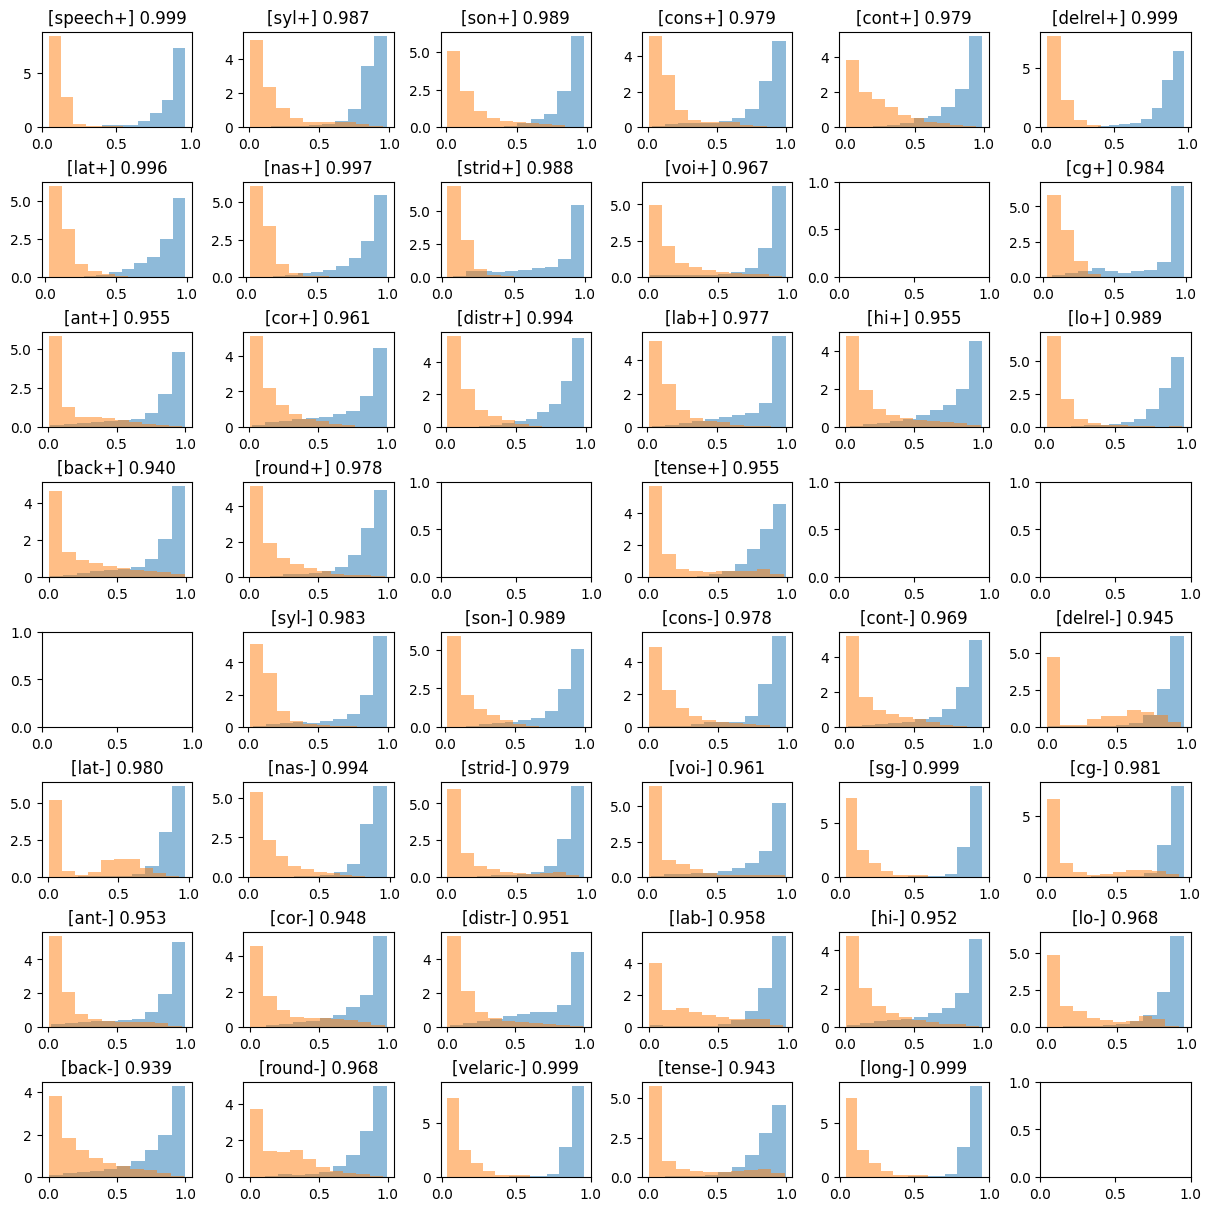

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


fig, axes = plt.subplots(8, len(pv.featnames)//8, figsize=(12, 12), constrained_layout=True)
for i, (ax, featname) in enumerate(zip(axes.flatten(), pv.featnames)):
    pos_phns, zero_phns = pv.split_phns(featname)
    if len(pos_phns) > 0 and len(zero_phns) > 0:
        # pos_vec = np.stack(df_train[df_train.ipa.isin(pos_phns)].feat.tolist())
        # zero_vec = np.stack(df_train[df_train.ipa.isin(zero_phns)].feat.tolist())
        pos_vec = np.stack(df_test_timit[df_test_timit.ipa.isin(pos_phns)].feat.tolist())
        zero_vec = np.stack(df_test_timit[df_test_timit.ipa.isin(zero_phns)].feat.tolist())

        with torch.no_grad():
            pos_dot = net(torch.FloatTensor(pos_vec))[1][:, i].numpy()
            zero_dot = net(torch.FloatTensor(zero_vec))[1][:, i].numpy()

        ax.hist(pos_dot, alpha=0.5, density=True)
        ax.hist(zero_dot, alpha=0.5, density=True)

        labels = np.array([1]*len(pos_dot) + [0]*len(zero_dot))
        scores = np.concatenate([pos_dot, zero_dot])
        auroc = roc_auc_score(labels, scores)

        ax.set_title(f"[{featname}] {auroc:.3f}")
plt.show()

speech+ count: 0, 410
velaric+ count: 0, 410
hitone+ count: 0, 410
hireg+ count: 0, 410
velaric- count: 410, 0
hitone- count: 0, 410
hireg- count: 0, 410


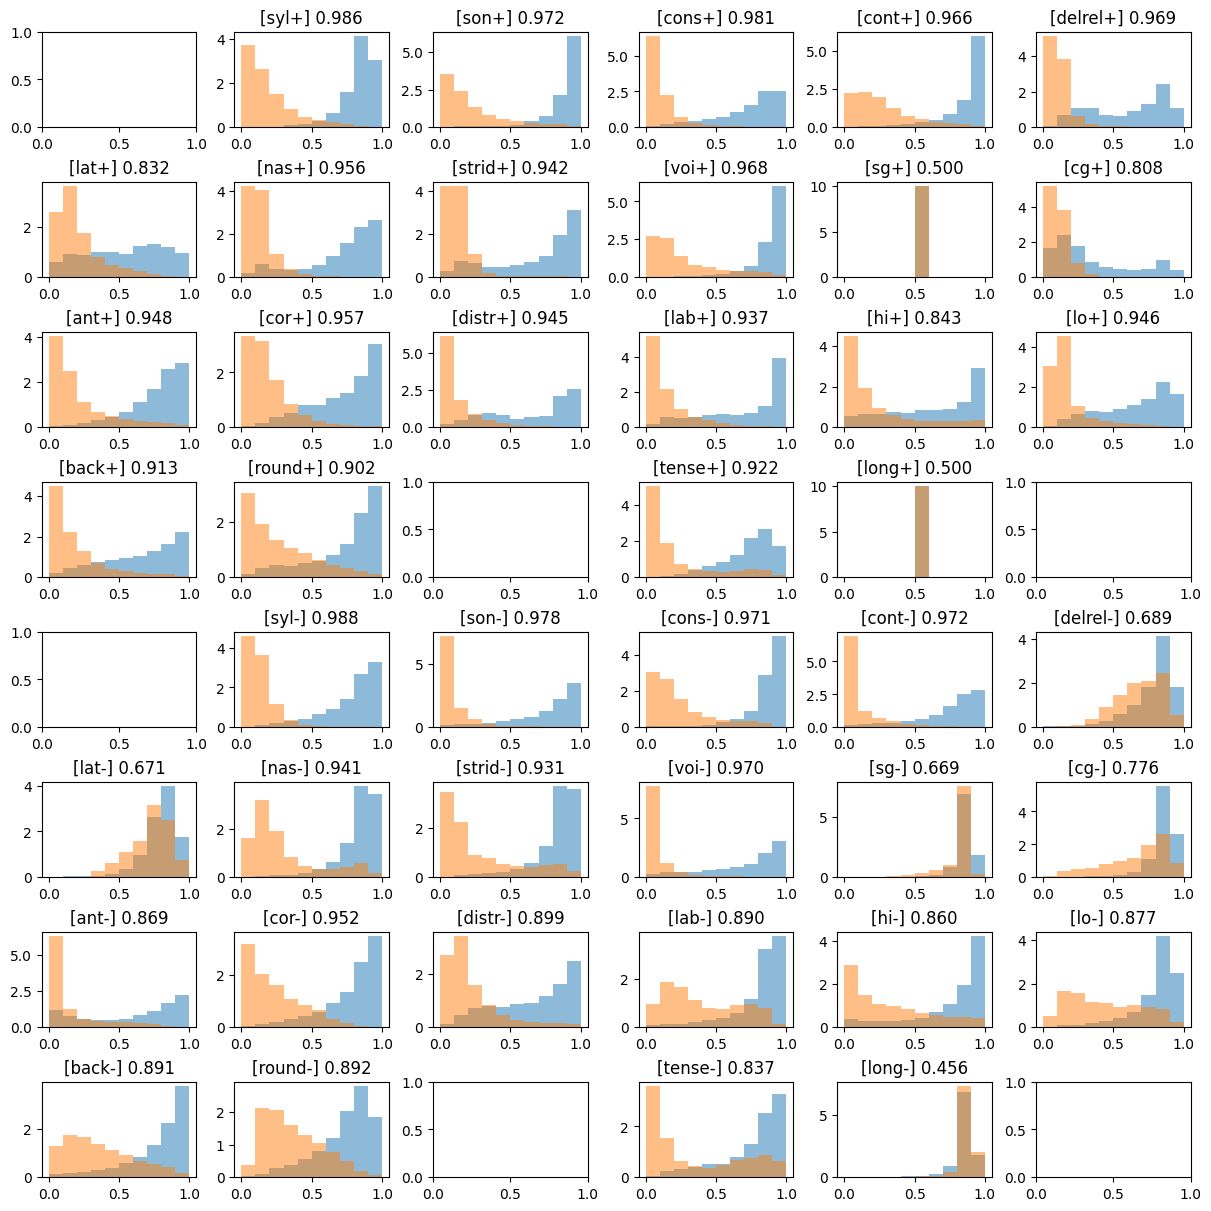

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


pv_va = PhonologicalVectors(df_test_va, df_test_va[~df_test_va.ipa.isna()].ipa.unique().tolist())

fig, axes = plt.subplots(8, len(pv_va.featnames)//8, figsize=(12, 12), constrained_layout=True)
for i, (ax, featname) in enumerate(zip(axes.flatten(), pv.featnames)):
    pos_phns, zero_phns = pv_va.split_phns(featname)
    if len(pos_phns) > 0 and len(zero_phns) > 0:
        pos_vec = np.stack(df_test_va[df_test_va.ipa.isin(pos_phns)].feat.tolist())
        zero_vec = np.stack(df_test_va[df_test_va.ipa.isin(zero_phns)].feat.tolist())

        with torch.no_grad():
            pos_dot = net(torch.FloatTensor(pos_vec))[1][:, i].numpy()
            zero_dot = net(torch.FloatTensor(zero_vec))[1][:, i].numpy()

        ax.hist(pos_dot, alpha=0.5, density=True, range=(0, 1))
        ax.hist(zero_dot, alpha=0.5, density=True, range=(0, 1))

        labels = np.array([1]*len(pos_dot) + [0]*len(zero_dot))
        scores = np.concatenate([pos_dot, zero_dot])
        auroc = roc_auc_score(labels, scores)

        ax.set_title(f"[{featname}] {auroc:.3f}")

plt.show()

In [69]:
feats = np.stack(df_test_timit.feat.tolist())
labels = np.stack(df_test_timit.ipa.tolist())

# feats = np.stack(df_test_va.feat.tolist())
# labels = np.stack(df_test_va.ipa.tolist())

with torch.no_grad():
    logits, phons = net(torch.FloatTensor(feats))

preds = np.array(pv.vocab)[logits.argmax(1).numpy()]


In [70]:
print("vad accuracy", np.mean(preds[labels == "_"] == "_"))

dst = panphon.distance.Distance()
errors = []
for p, l in zip(preds[labels != "_"], labels[labels != "_"]):
    if p == "_":
        errors.append(1.0)
    else:
        errors.append(dst.feature_edit_distance(p, l))
print("pfer", np.mean(errors))

vad accuracy 0.9901785714285715
pfer 0.10327965699426259


In [73]:
from transformers import Wav2Vec2FeatureExtractor, AutoModel

processor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-large")
model = AutoModel.from_pretrained("microsoft/wavlm-large")

/Users/kwangheechoi/workspace/phonetic-arithmetic/envs/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/kwangheechoi/workspace/phonetic-arithmetic/envs/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of the model checkpoint at microsoft/wavlm-large were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining mo

In [77]:
import librosa


x, sr = librosa.load("/Users/kwangheechoi/Desktop/test.wav", sr=16000)
inputs = processor(raw_speech=[x], sampling_rate=16000, padding=False, return_tensors="pt")
outputs = model(**inputs)
feats = outputs.last_hidden_state.cpu().detach()[0]

In [82]:
with torch.no_grad():
    logits, phons = net(torch.FloatTensor(feats))
preds = np.array(pv.vocab)[logits.argmax(1).numpy()]
print("".join(preds))

_____________________________________qˀqˀɦ̰ʌ̈ɤ̙ʌ̙ɛ̃nnndjʌ̙ɤ̙ɔˤɔˤɔˤɔ̃õˤɑ̙ɑ̈ɤ̙ʌ̙rzsð̺ɛ̈ïïɘ̘ˠɘ̘ˠïïïɘ̘ˠɘ̘ˠɤ̙ˠʊ̈ʊ̈ɔ̈ɔ̈ɔ̈ɔ̈ɛ̈ʌ̙ə̯ə̯ɦq___________________t_______qpptssθ̺ïïɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠi̯rrɘ̘ˠɘ̙ˠʏ̈ʊ̈ɤ̘ˠĩmmmɛ̈ʌ̙ʌ̙ɛ̃n̩nnntt͡s̻t͡ʃt͡ʃt͡ʃɽ̻ɘ̙ˠʏ̈o̘ˠɨ̈ɢʲɡ͡bwʲwʲɔ̈ɔˤɑ̙ɤ̙ɛ̈r̃ɲʲɲʲjɘ̘ˠɘ̘ˠɘ̘ˠɘ̘ˠĩɱmmmɱnr̃ïɘ̘ˠïïdpt̪̼d̪ɛ̈ɘˤɘˤɘˤɘˤɑ̈ɑ̙ɤ̙ɤ̙_______
